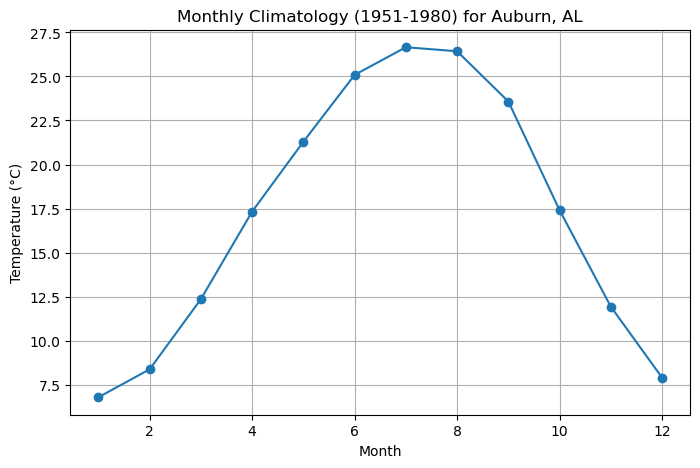

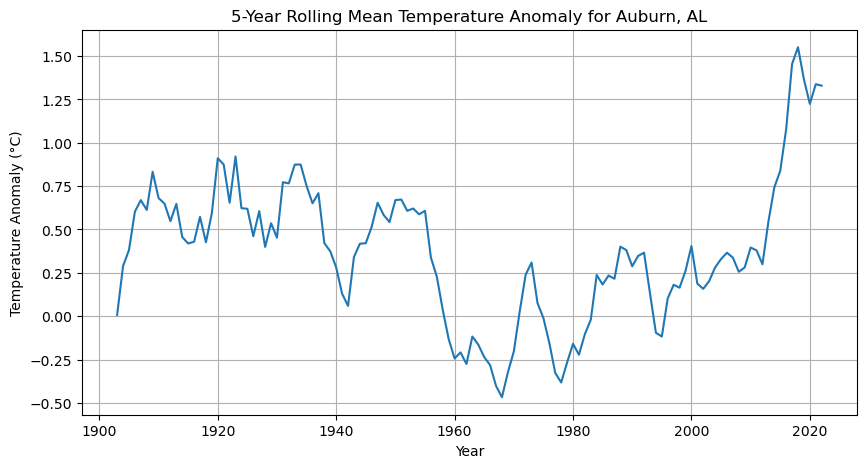

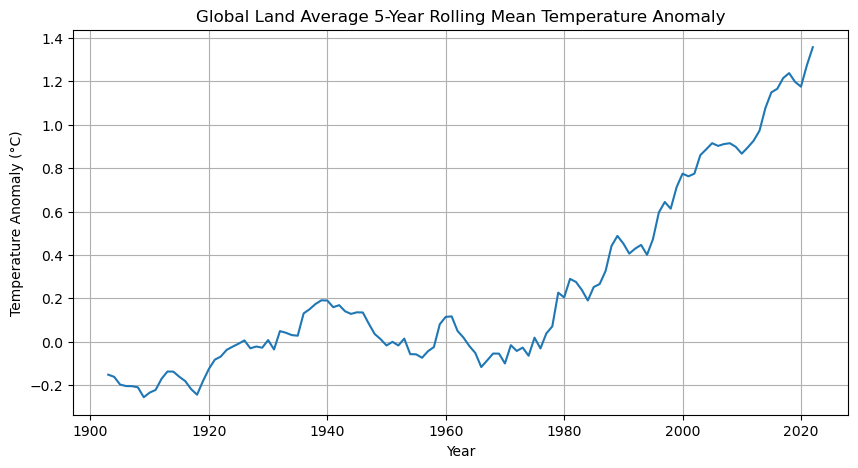

In [6]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file = "/glade/work/kumar34/GSEI2070_DAT/cru_ts4.09.1901.2024.tmp.dat.nc"
ds = xr.open_dataset(file)
tmp = ds["tmp"]

auburn_lat = 32.61
auburn_lon = -85.48

if float(tmp.lon.min()) >= 0:
    auburn_lon_use = auburn_lon % 360
else:
    auburn_lon_use = auburn_lon

ref = tmp.sel(time=slice("1951-01-01", "1980-12-31"))
monthly_clim = ref.groupby("time.month").mean("time")

auburn_clim = monthly_clim.sel(lat=auburn_lat, lon=auburn_lon_use, method="nearest")

plt.figure(figsize=(8,5))
auburn_clim.plot(marker="o")
plt.title("Monthly Climatology (1951-1980) for Auburn, AL")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.savefig("auburn_monthly_climatology.png", dpi=300, bbox_inches="tight")
plt.show()

monthly_anom = tmp.groupby("time.month") - monthly_clim

auburn_anom = monthly_anom.sel(lat=auburn_lat, lon=auburn_lon_use, method="nearest")
auburn_annual_anom = auburn_anom.groupby("time.year").mean("time")
auburn_annual_anom_5yr = auburn_annual_anom.rolling(year=5, center=True).mean()

plt.figure(figsize=(10,5))
auburn_annual_anom_5yr.plot()
plt.title("5-Year Rolling Mean Temperature Anomaly for Auburn, AL")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.savefig("auburn_5yr_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()

weights = np.cos(np.deg2rad(monthly_anom["lat"]))
global_monthly_anom = monthly_anom.weighted(weights).mean(dim=("lat", "lon"))
global_annual_anom = global_monthly_anom.groupby("time.year").mean("time")
global_annual_anom_5yr = global_annual_anom.rolling(year=5, center=True).mean()

plt.figure(figsize=(10,5))
global_annual_anom_5yr.plot()
plt.title("Global Land Average 5-Year Rolling Mean Temperature Anomaly")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)
plt.savefig("global_land_5yr_anomaly.png", dpi=300, bbox_inches="tight")
plt.show()